In [1]:
# ---------------------------
# 1. Import Required Libraries
# ---------------------------
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# ---------------------------
# 2. Set Random Seeds
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [9]:
# ---------------------------
# 3. Dataset Paths
# ---------------------------
base_path = "DevanagariHandwrittenDigitDataset"

train_dir = os.path.join(base_path, "Train")
test_dir = os.path.join(base_path, "Test")


In [10]:
# ---------------------------
# 4. Function to Load Dataset using PIL
# ---------------------------
def load_images_from_folder(data_dir, img_size=(28, 28)):
    images = []
    labels = []
    class_names = []

    folders = sorted([
        folder for folder in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, folder))
    ])

    for label, folder_name in enumerate(folders):
        folder_path = os.path.join(data_dir, folder_name)
        class_names.append(folder_name)

        for file_name in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file_name)

            try:
                img = Image.open(file_path).convert("L")   # grayscale
                img = img.resize(img_size)
                img = np.array(img, dtype=np.float32)

                images.append(img)
                labels.append(label)

            except Exception as e:
                print(f"Skipping {file_path}: {e}")

    images = np.array(images, dtype=np.float32)
    labels = np.array(labels)

    return images, labels, class_names


In [11]:
# ---------------------------
# 5. Load Train and Test Data
# ---------------------------
x_train, y_train, train_classes = load_images_from_folder(train_dir)
x_test, y_test, test_classes = load_images_from_folder(test_dir)

print("Train images shape before preprocessing:", x_train.shape)
print("Test images shape before preprocessing:", x_test.shape)
print("Classes:", train_classes)

Train images shape before preprocessing: (17000, 28, 28)
Test images shape before preprocessing: (3000, 28, 28)
Classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']


In [12]:
# ---------------------------
# 6. Normalize and Reshape
# ---------------------------
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

print("Train images shape after preprocessing:", x_train.shape)
print("Test images shape after preprocessing:", x_test.shape)

Train images shape after preprocessing: (17000, 28, 28, 1)
Test images shape after preprocessing: (3000, 28, 28, 1)


In [13]:
# ---------------------------
# 7. Add Gaussian Noise
# ---------------------------
def add_gaussian_noise(data, noise_factor=0.5):
    noisy = data + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=data.shape)
    noisy = np.clip(noisy, 0.0, 1.0)
    return noisy

noise_factor = 0.5
x_train_noisy = add_gaussian_noise(x_train, noise_factor)
x_test_noisy = add_gaussian_noise(x_test, noise_factor)

print("Noisy training data shape:", x_train_noisy.shape)
print("Noisy testing data shape:", x_test_noisy.shape)

Noisy training data shape: (17000, 28, 28, 1)
Noisy testing data shape: (3000, 28, 28, 1)


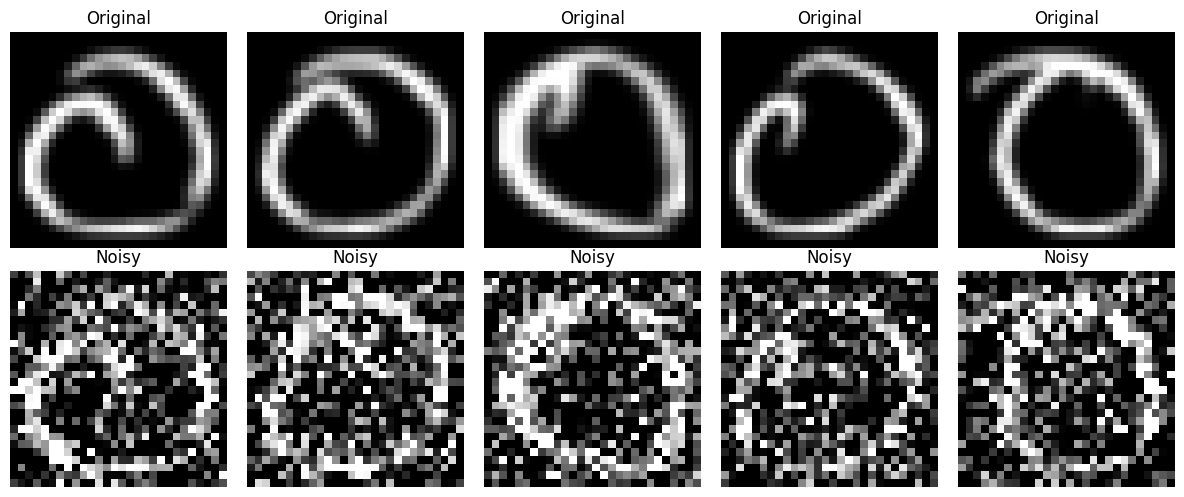

In [14]:
# ---------------------------
# 8. Visualize Original and Noisy Images
# ---------------------------
def show_original_and_noisy(clean, noisy, n=5):
    plt.figure(figsize=(12, 5))

    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(clean[i].reshape(28, 28), cmap="gray")
        plt.title("Original")
        plt.axis("off")

        # Noisy
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(noisy[i].reshape(28, 28), cmap="gray")
        plt.title("Noisy")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_original_and_noisy(x_train, x_train_noisy, n=5)

In [15]:
# ---------------------------
# 9. Build Denoising Convolutional Autoencoder
# ---------------------------
def build_autoencoder(input_shape=(28, 28, 1)):
    input_img = Input(shape=input_shape)

    # Encoder
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)

    # Bottleneck
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)

    # Decoder
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)

    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)

    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')

    return autoencoder

In [16]:
# ---------------------------
# 10. Create Model
# ---------------------------
autoencoder = build_autoencoder()
autoencoder.summary()


# ---------------------------
# 11. Train the Autoencoder
# ---------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[early_stop]
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,217 (723.50 KB)

 Trainable params: 185,217 (723.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 14s 93ms/step - loss: 0.3962 - val_loss: 0.2046
Epoch 2/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 12s 93ms/step - loss: 0.2017 - val_loss: 0.1922
Epoch 3/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 12s 93ms/step - loss: 0.1919 - val_loss: 0.1873
Epoch 4/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - loss: 0.1874 - val_loss: 0.1843
Epoch 5/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 13s 95ms/step - loss: 0.1843 - val_loss: 0.1821
Epoch 6/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - loss: 0.1822 - val_loss: 0.1806
Epoch 7/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 13s 97ms/step - loss: 0.1807 - val_loss: 0.1793
Epoch 8/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 13s 95ms/step - loss: 0.1794 - val_loss: 0.1783
Epoch 9/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 13s 97ms/step - loss: 0.1784 - val_loss: 0.1775
Epoch 10/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 13s 100ms/step - loss: 0.1775 - val_loss: 0.1768


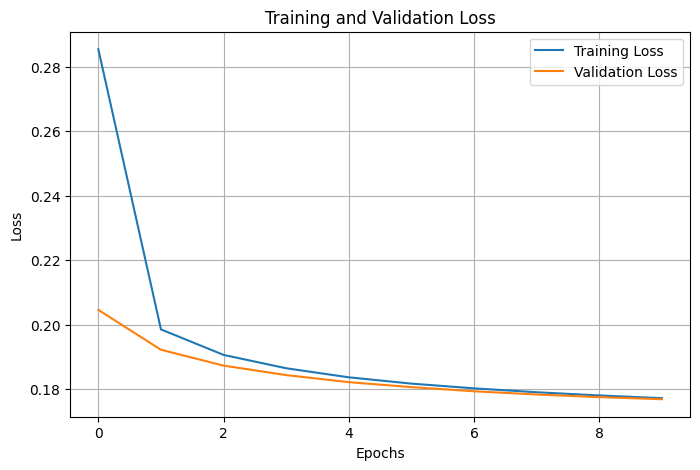

In [17]:
# ---------------------------
# 12. Plot Training and Validation Loss
# ---------------------------
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


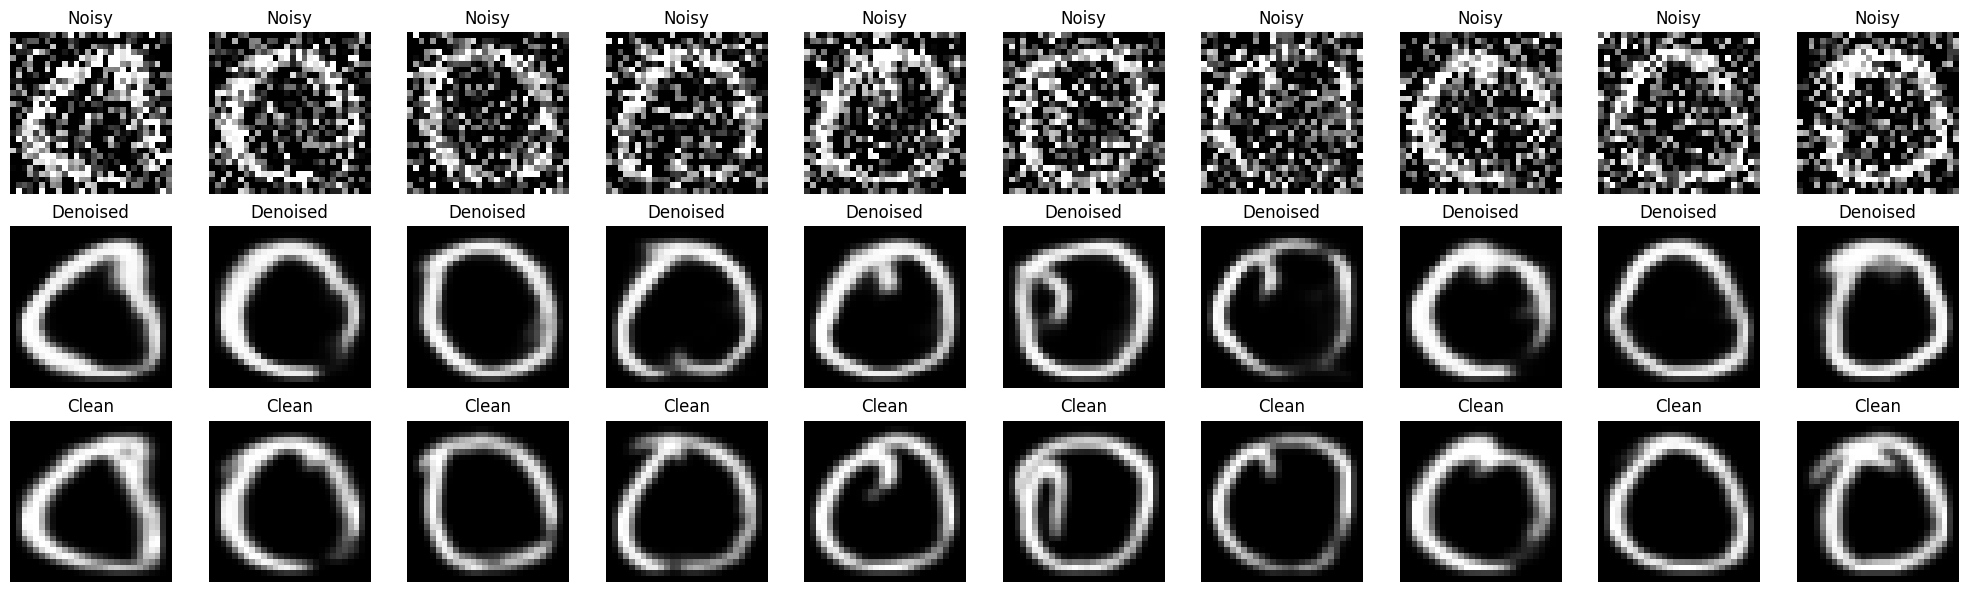

In [19]:
# ---------------------------
# 13. Predict Denoised Images
# ---------------------------
denoised_images = autoencoder.predict(x_test_noisy)


# ---------------------------
# 14. Visualize Noisy, Denoised, and Clean Images
# ---------------------------
def plot_results(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))

    for i in range(n):
        # Noisy
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy")
        plt.axis('off')

        # Denoised
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised")
        plt.axis('off')

        # Clean
        ax = plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
plot_results(x_test_noisy, denoised_images, x_test, n=10)    


In [20]:
# ---------------------------
# 15. Evaluate Model
# ---------------------------
test_loss = autoencoder.evaluate(x_test_noisy, x_test, verbose=0)
print("Test Loss:", test_loss)


Test Loss: 0.17684519290924072


In [21]:
# ---------------------------
# 16. Save Model
# ---------------------------
autoencoder.save("devnagari_denoising_autoencoder.h5")
print("Model saved successfully.")

Model saved successfully.
